# INSTRUCTOR SOLUTION: RL Fundamentals and MDPs
## AIAT 123 - Reinforcement Learning

**⚠️ INSTRUCTOR USE ONLY**

This solution demonstrates the complete implementation.


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

import numpy as np

np.set_printoptions(precision=2, suppress=True)

N_ROWS, N_COLS = 3, 3
N_STATES = N_ROWS * N_COLS
ACTIONS = ["up", "right", "down", "left"]
ACTION_TO_DELTA = {
    0: (-1, 0),
    1: (0, 1),
    2: (1, 0),
    3: (0, -1),
}
ACTION_TO_ARROW = {0: "↑", 1: "→", 2: "↓", 3: "←"}
GOAL_STATE = 8
PIT_STATE = 6
TERMINAL_STATES = {GOAL_STATE, PIT_STATE}
GAMMA = 0.90


def to_pos(state):
    return divmod(state, N_COLS)


def to_state(row, col):
    return row * N_COLS + col


def transition(state, action):
    if state in TERMINAL_STATES:
        return state, 0.0

    row, col = to_pos(state)
    d_row, d_col = ACTION_TO_DELTA[action]
    next_row = min(max(row + d_row, 0), N_ROWS - 1)
    next_col = min(max(col + d_col, 0), N_COLS - 1)
    next_state = to_state(next_row, next_col)

    if next_state == GOAL_STATE:
        return next_state, 10.0
    if next_state == PIT_STATE:
        return next_state, -10.0
    return next_state, -1.0


def print_values(values):
    for r in range(N_ROWS):
        row = []
        for c in range(N_COLS):
            s = to_state(r, c)
            if s == GOAL_STATE:
                row.append("  G   ")
            elif s == PIT_STATE:
                row.append("  P   ")
            else:
                row.append(f"{values[s]:6.2f}")
        print(" ".join(row))


def print_policy(policy):
    for r in range(N_ROWS):
        row = []
        for c in range(N_COLS):
            s = to_state(r, c)
            if s == GOAL_STATE:
                row.append(" G ")
            elif s == PIT_STATE:
                row.append(" P ")
            else:
                row.append(f" {ACTION_TO_ARROW[policy[s]]} ")
        print(" ".join(row))


print("✅ Setup complete!")
print("State layout: 0 1 2 / 3 4 5 / P 7 G")

✅ Setup complete!
State layout: 0 1 2 / 3 4 5 / P 7 G


## Student Support Pack

Use this section to study the solution actively, not passively.

### Key Terms
- State: where the agent is.
- Action: what the agent can do.
- Reward: immediate feedback.
- Policy: the action rule.

### Quick Check
- Can you separate environment pieces from agent pieces?
- Why do we define states and actions before solving?
- What part of the notebook tells you what success means?

### Common Mistakes
- Mixing state with reward.
- Thinking the policy creates the reward.
- Reading one transition as the whole problem.


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Final computation: this cell usually summarizes the lesson, evaluates the result, or compares strategies.
# Pause here and ask what the numbers or tables say about the decision-making process.

# Task 1: Define the MDP
print("Task 1: MDP Definition")
print("- States: integers 0 to 8 in a 3x3 grid")
print("- Actions: up, right, down, left")
print("- Terminal states: pit=6, goal=8")
print("- Reward: +10 for goal, -10 for pit, -1 otherwise")
print()


# Task 2: Value Iteration
def value_iteration(gamma=GAMMA, theta=1e-6):
    values = np.zeros(N_STATES)
    while True:
        delta = 0.0
        new_values = values.copy()
        for state in range(N_STATES):
            if state in TERMINAL_STATES:
                continue
            action_returns = []
            for action in range(len(ACTIONS)):
                next_state, reward = transition(state, action)
                action_returns.append(reward + gamma * values[next_state])
            best_value = max(action_returns)
            delta = max(delta, abs(best_value - values[state]))
            new_values[state] = best_value
        values = new_values
        if delta < theta:
            break
    return values


def greedy_policy_from_values(values, gamma=GAMMA):
    policy = np.zeros(N_STATES, dtype=int)
    for state in range(N_STATES):
        if state in TERMINAL_STATES:
            continue
        action_returns = []
        for action in range(len(ACTIONS)):
            next_state, reward = transition(state, action)
            action_returns.append(reward + gamma * values[next_state])
        policy[state] = int(np.argmax(action_returns))
    return policy


optimal_values = value_iteration()
optimal_policy = greedy_policy_from_values(optimal_values)

print("Task 2: Optimal values")
print_values(optimal_values)
print("\nTask 2: Greedy policy from optimal values")
print_policy(optimal_policy)
print()


# Task 3: Policy Evaluation and Comparison
def evaluate_policy(policy, gamma=GAMMA, theta=1e-6):
    values = np.zeros(N_STATES)
    while True:
        delta = 0.0
        for state in range(N_STATES):
            if state in TERMINAL_STATES:
                continue
            action = policy[state]
            next_state, reward = transition(state, action)
            new_value = reward + gamma * values[next_state]
            delta = max(delta, abs(new_value - values[state]))
            values[state] = new_value
        if delta < theta:
            break
    return values


right_then_down_policy = np.array([
    1, 1, 2,
    1, 1, 2,
    0, 1, 0,
])

safe_up_policy = np.array([
    1, 1, 2,
    0, 0, 2,
    0, 0, 0,
])

values_right_down = evaluate_policy(right_then_down_policy)
values_safe = evaluate_policy(safe_up_policy)

print("Task 3: Policy comparison")
print("\nPolicy A: right then down")
print_policy(right_then_down_policy)
print_values(values_right_down)

print("\nPolicy B: safer movement away from the pit")
print_policy(safe_up_policy)
print_values(values_safe)

print("\nInstructor note:")
print("The better policy is the one that reaches the goal while reliably avoiding the pit.")
print("Students should explain *why* the values differ, not just print the arrays.")

Task 1: MDP Definition
- States: integers 0 to 8 in a 3x3 grid
- Actions: up, right, down, left
- Terminal states: pit=6, goal=8
- Reward: +10 for goal, -10 for pit, -1 otherwise

Task 2: Optimal values
  4.58   6.20   8.00
  6.20   8.00  10.00
  P     10.00   G   

Task 2: Greedy policy from optimal values
 →   →   ↓ 
 →   →   ↓ 
 P   →   G 

Task 3: Policy comparison

Policy A: right then down
 →   →   ↓ 
 →   →   ↓ 
 P   →   G 
  4.58   6.20   8.00
  6.20   8.00  10.00
  P     10.00   G   

Policy B: safer movement away from the pit
 →   →   ↓ 
 ↑   ↑   ↓ 
 P   ↑   G 
  4.58   6.20   8.00
  3.12   4.58  10.00
  P      3.12   G   

Instructor note:
The better policy is the one that reaches the goal while reliably avoiding the pit.
Students should explain *why* the values differ, not just print the arrays.


### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


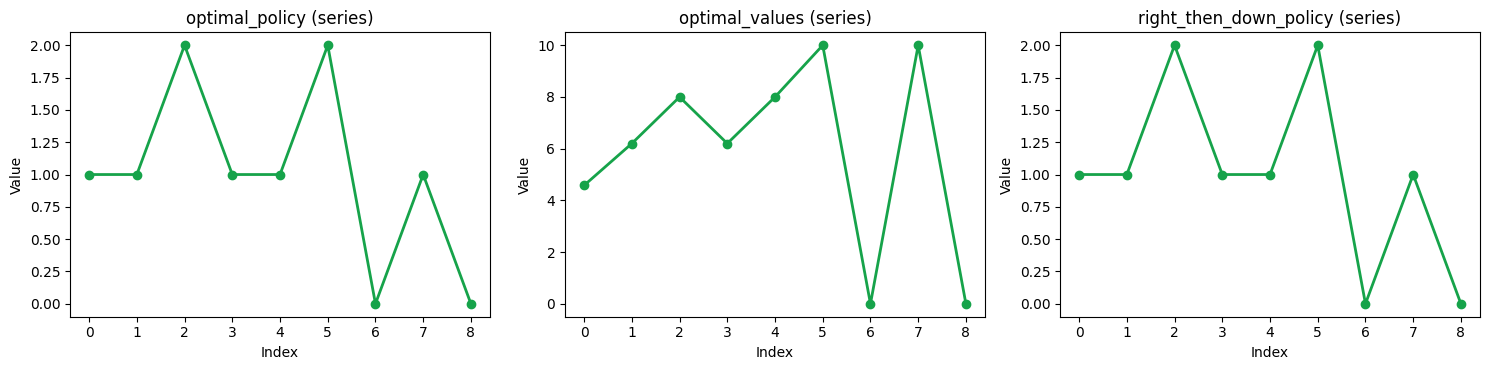

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
